# Field Development Decision Engine

This notebook demonstrates the new field-development decision-engine workflow with workspace Java classes loaded through `devtools/neqsim_dev_setup.py`. It compares standardized development templates, plots lifecycle emissions, ranks alternatives with MCDA, and runs a capital-constrained portfolio optimization.

In [1]:
import importlib.util
import os
import sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
DEVTOOLS_DIR = PROJECT_ROOT / "devtools"
sys.path.insert(0, str(DEVTOOLS_DIR))

setup_path = DEVTOOLS_DIR / "neqsim_dev_setup.py"
setup_spec = importlib.util.spec_from_file_location("neqsim_dev_setup", setup_path)
if setup_spec is None or setup_spec.loader is None:
    raise RuntimeError(f"Could not load devtools setup module from {setup_path}")
setup_module = importlib.util.module_from_spec(setup_spec)
setup_spec.loader.exec_module(setup_module)

neqsim_init = setup_module.neqsim_init
neqsim_classes = setup_module.neqsim_classes

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)
NEQSIM_MODE = "devtools"
NOTEBOOK_DIR = (PROJECT_ROOT / "examples" / "notebooks").resolve()
FIGURES_DIR = NOTEBOOK_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print("NeqSim loaded via devtools workspace classes")

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\.m2\repository\com\h2database\h2\2.4.240\h2-2.4.240.jar
  4. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-api\2.25.4\log4j-api-2.25.4.jar
  5. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-core\2.25.4\log4j-core-2.25.4.jar
  6. C:\Users\ESOL\.m2\repository\com\thoughtworks\xstream\xstream\1.4.21\xstream-1.4.21.jar
  7. C:\Users\ESOL\.m2\repository\io\github\x-stream\mxparser\1.2.2\mxparser-1.2.2.jar
  8. C:\Users\ESOL\.m2\repository\xmlpull\xmlpull\1.1.3.1\xmlpull-1.1.3.1.jar
  9. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-lang3\3.20.0\commons-lang3-3.20.0.jar
  10. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-math3\3.6.1\commons-math3-3.6.1.jar
  11. C:\Users\ESOL\.m2\repository\org\ejml\ejml-all\0.44.0\ejml-all-0.44.0.jar
  12

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

GreenfieldConceptFactory = ns.JClass("neqsim.process.fielddevelopment.concept.GreenfieldConceptFactory")
FieldDevelopmentReportExporter = ns.JClass("neqsim.process.fielddevelopment.reporting.FieldDevelopmentReportExporter")
DevelopmentOptionRanker = ns.JClass("neqsim.process.fielddevelopment.evaluation.DevelopmentOptionRanker")
PortfolioOptimizer = ns.JClass("neqsim.process.fielddevelopment.economics.PortfolioOptimizer")
ArrayList = ns.JClass("java.util.ArrayList")

Criterion = DevelopmentOptionRanker.Criterion
ProjectType = PortfolioOptimizer.ProjectType
OptimizationStrategy = PortfolioOptimizer.OptimizationStrategy

plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.grid": True})


def java_map_to_dict(java_map):
    return {int(entry.getKey()): float(entry.getValue()) for entry in java_map.entrySet()}

## 1. Compare Standardized Development Templates

The template factory creates comparable cases with concept basis, facility blocks, CAPEX, production profiles, lifecycle emissions, screening economics, and P10/P50/P90 assumptions attached to the same object.

In [3]:
templates = [
    GreenfieldConceptFactory.subseaTieback("Satellite tieback"),
    GreenfieldConceptFactory.standaloneFpso("Standalone FPSO"),
    GreenfieldConceptFactory.fixedPlatform("Fixed platform"),
    GreenfieldConceptFactory.subseaToShore("Subsea to shore"),
    GreenfieldConceptFactory.phasedBrownfieldExpansion("Phased brownfield"),
]

java_templates = ArrayList()
for template in templates:
    java_templates.add(template)

rows = []
for template in templates:
    uncertainty = template.getUncertainty()
    resource = uncertainty.getResource()
    capex = uncertainty.getCapex()
    lifecycle = template.getLifecycleEmissionsProfile()
    rows.append({
        "Case": str(template.getCaseName()),
        "Type": str(template.getCaseType()),
        "CAPEX (MUSD)": template.getTotalCapexMusd(),
        "NPV (MUSD)": template.getEconomics().getNpv(),
        "Power (MW)": template.getPowerMw(),
        "Lifecycle CO2 (kt)": lifecycle.getTotalLifecycleEmissionsTonnes() / 1000.0,
        "CO2 intensity (kg/boe)": lifecycle.getAverageIntensityKgCO2PerBoe(),
        "Resource P50": resource.getP50(),
        "Resource unit": str(resource.getUnit()),
        "CAPEX P10 (MUSD)": capex.getP10(),
        "CAPEX P90 (MUSD)": capex.getP90(),
        "Facility blocks": template.getFacilityConfig().getBlocks().size(),
    })

templates_df = pd.DataFrame(rows)
display(templates_df.round(2))

,Case,Type,CAPEX (MUSD),NPV (MUSD),Power (MW),Lifecycle CO2 (kt),CO2 intensity (kg/boe),Resource P50,Resource unit,CAPEX P10 (MUSD),CAPEX P90 (MUSD),Facility blocks
0,Satellite tieback,Subsea tieback,830.0,-73.73,3.0,158.28,113.06,12.0,GSm3,705.50,1079.0,4
1,Standalone FPSO,Standalone FPSO,1815.0,-106.51,2.0,22.89,0.42,120.0,MMbbl,1542.75,2359.5,6
2,Fixed platform,Fixed platform,1085.0,540.07,2.0,31.33,0.42,150.0,MMbbl,922.25,1410.5,6
3,Subsea to shore,Subsea-to-shore,780.0,458.60,3.0,126.86,30.21,35.0,GSm3,663.00,1014.0,4
4,Phased brownfield,Phased brownfield expansion,840.0,-151.15,3.0,289.32,160.74,18.0,GSm3,714.00,1092.0,6


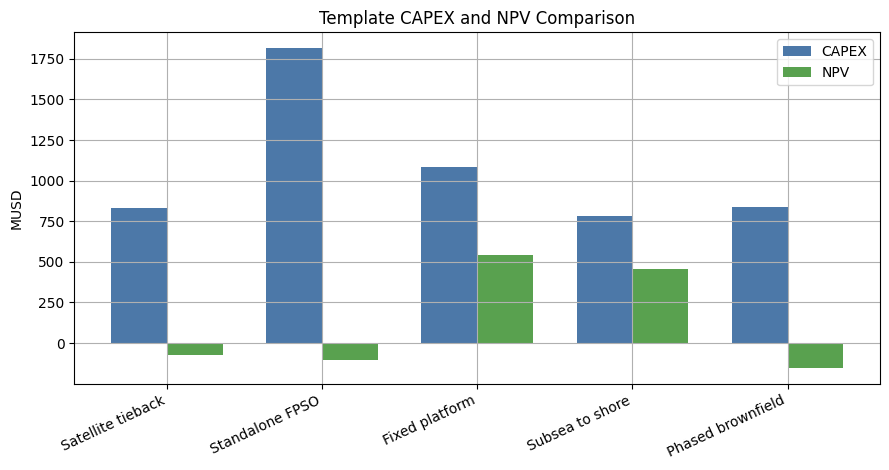

In [4]:
labels = templates_df["Case"].tolist()
x = np.arange(len(labels))
width = 0.36

fig, ax1 = plt.subplots()
ax1.bar(x - width / 2, templates_df["CAPEX (MUSD)"], width, label="CAPEX", color="#4C78A8")
ax1.bar(x + width / 2, templates_df["NPV (MUSD)"], width, label="NPV", color="#59A14F")
ax1.set_ylabel("MUSD")
ax1.set_title("Template CAPEX and NPV Comparison")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=25, ha="right")
ax1.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "field_development_template_capex_npv.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure discussion.** The standardized templates expose the expected screening trade-off: lower-CAPEX tiebacks and brownfield expansions compete with larger standalone developments that may carry higher absolute NPV. Keeping CAPEX, production profile, emissions, and economics on the template object makes later ranking transparent instead of relying on disconnected notebook tables.

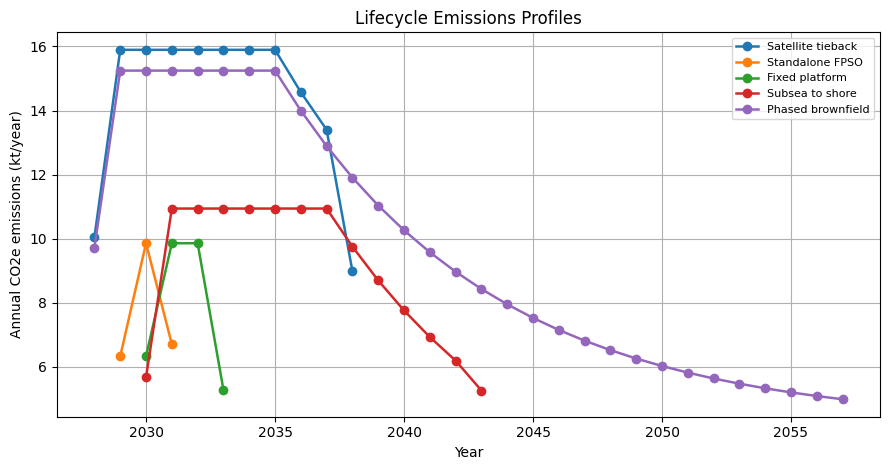

In [5]:
fig, ax = plt.subplots()
for template in templates:
    profile = template.getLifecycleEmissionsProfile()
    annual = list(profile.getAnnualEmissions())
    years = [item.getYear() for item in annual]
    emissions_kt = [item.getTotalEmissionsTonnes() / 1000.0 for item in annual]
    if years:
        ax.plot(years, emissions_kt, marker="o", linewidth=1.8, label=str(template.getCaseName()))

ax.set_title("Lifecycle Emissions Profiles")
ax.set_xlabel("Year")
ax.set_ylabel("Annual CO2e emissions (kt/year)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "field_development_lifecycle_emissions.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure discussion.** Lifecycle emissions follow the production load factor and power-supply assumption attached to each concept. The plot is useful in teaching workflows because it turns the environmental criterion in MCDA from a single opaque number into a time-series consequence of the facility concept.

## 2. Rank Development Options With MCDA

The ranker normalizes criteria, accounts for whether higher or lower values are preferred, and combines them with a named weight profile.

In [6]:
ranker = DevelopmentOptionRanker()
ranker.setWeightProfile("balanced")

technical_risk = {
    "Subsea tieback": 0.30,
    "Standalone FPSO": 0.58,
    "Fixed platform": 0.48,
    "Subsea-to-shore": 0.68,
    "Phased brownfield expansion": 0.25,
}
execution_risk = {
    "Subsea tieback": 0.35,
    "Standalone FPSO": 0.62,
    "Fixed platform": 0.52,
    "Subsea-to-shore": 0.70,
    "Phased brownfield expansion": 0.28,
}
strategic_fit = {
    "Subsea tieback": 0.76,
    "Standalone FPSO": 0.70,
    "Fixed platform": 0.68,
    "Subsea-to-shore": 0.82,
    "Phased brownfield expansion": 0.88,
}

for template in templates:
    case_type = str(template.getCaseType())
    option = ranker.addOption(str(template.getCaseName()))
    capex = template.getTotalCapexMusd()
    npv = template.getEconomics().getNpv()
    lifecycle = template.getLifecycleEmissionsProfile()
    option.setScore(Criterion.NPV, npv)
    option.setScore(Criterion.CAPITAL_EFFICIENCY, npv / capex if capex else 0.0)
    option.setScore(Criterion.CO2_INTENSITY, lifecycle.getAverageIntensityKgCO2PerBoe())
    option.setScore(Criterion.TECHNICAL_RISK, technical_risk.get(case_type, 0.50))
    option.setScore(Criterion.EXECUTION_RISK, execution_risk.get(case_type, 0.50))
    option.setScore(Criterion.STRATEGIC_FIT, strategic_fit.get(case_type, 0.70))
    option.setScore(Criterion.HSE_RISK, 0.25 + 0.35 * technical_risk.get(case_type, 0.50))

ranking = ranker.rank()
ranking_rows = []
for option in ranking.getRankedOptions():
    ranking_rows.append({
        "Rank": option.getRank(),
        "Option": str(option.getName()),
        "Weighted score": option.getWeightedScore(),
        "NPV (MUSD)": option.getScore(Criterion.NPV),
        "CO2 intensity (kg/boe)": option.getScore(Criterion.CO2_INTENSITY),
        "Technical risk": option.getScore(Criterion.TECHNICAL_RISK),
    })
ranking_df = pd.DataFrame(ranking_rows)
display(ranking_df.round(3))
print(ranking.generateReport())

,Rank,Option,Weighted score,NPV (MUSD),CO2 intensity (kg/boe),Technical risk
0,1,Fixed platform,0.642,540.071,0.417,0.48
1,2,Phased brownfield,0.550,-151.152,160.739,0.25
2,3,Satellite tieback,0.509,-73.732,113.058,0.30
3,4,Subsea to shore,0.469,458.599,30.206,0.68
4,5,Standalone FPSO,0.287,-106.507,0.423,0.58


=== DEVELOPMENT OPTION RANKING ===

RANKING SUMMARY:
Rank  Option                           Score
------------------------------------------------
1     Fixed platform                   0.642
2     Phased brownfield                0.550
3     Satellite tieback                0.509
4     Subsea to shore                  0.469
5     Standalone FPSO                  0.287

CRITERIA WEIGHTS:
  HSE Risk                 : 15%
  NPV                      : 20%
  Execution Risk           : 15%
  Strategic Fit            : 10%
  Capital Efficiency       : 10%
  CO2 Intensity            : 15%
  Technical Risk           : 15%

DETAILED SCORES:

1. Fixed platform (Score: 0.642)
   HSE Risk                 :     0.42 0-1 (normalized: 0.47)
   NPV                      :   540.07 MUSD (normalized: 1.00)
   Execution Risk           :     0.52 0-1 (normalized: 0.43)
   Strategic Fit            :     0.68 0-1 (normalized: 0.00)
   Capital Efficiency       :     0.50 ratio (normalized: 0.88)
   CO2 Intens

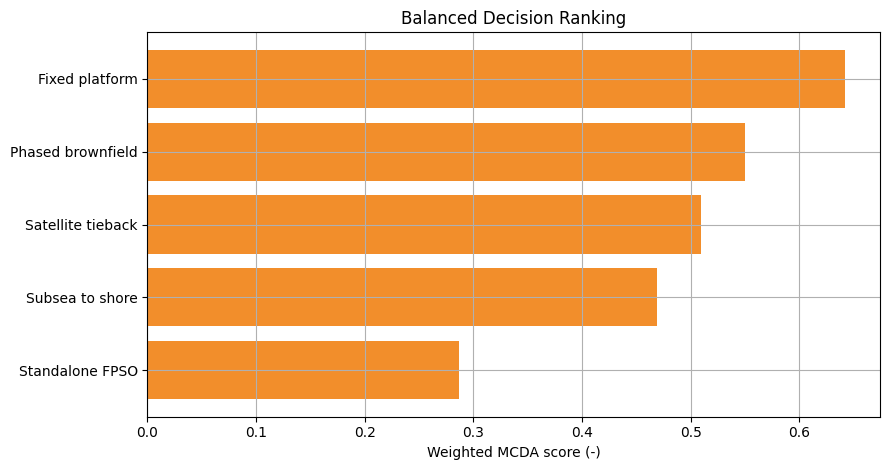

In [7]:
fig, ax = plt.subplots()
ranking_plot = ranking_df.sort_values("Weighted score")
ax.barh(ranking_plot["Option"], ranking_plot["Weighted score"], color="#F28E2B")
ax.set_xlabel("Weighted MCDA score (-)")
ax.set_title("Balanced Decision Ranking")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "field_development_mcda_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure discussion.** The MCDA score rewards concepts that combine attractive economics with lower emissions and lower execution risk. This makes the ranking defensible in a concept-selection class because changing the weight profile or risk assumptions changes the result in a traceable way.

## 3. Select a Capital-Constrained Portfolio

Portfolio optimization turns concept economics into a project-selection problem with annual budget limits, project types, probabilities of success, and strategy-dependent selection.

In [8]:
optimizer = PortfolioOptimizer()
optimizer.addProject("Alpha tieback", 360.0, 560.0, ProjectType.TIEBACK, 0.90)
optimizer.addProject("Beta standalone FPSO", 1650.0, 1350.0, ProjectType.DEVELOPMENT, 0.72)
optimizer.addProject("Gamma subsea to shore", 1220.0, 980.0, ProjectType.INFRASTRUCTURE, 0.78)
optimizer.addProject("Delta IOR", 180.0, 310.0, ProjectType.IOR, 0.94)
optimizer.addProject("Epsilon exploration", 240.0, 900.0, ProjectType.EXPLORATION, 0.32)
optimizer.setAnnualBudget(2028, 850.0)
optimizer.setAnnualBudget(2029, 900.0)
optimizer.setAnnualBudget(2030, 700.0)
optimizer.setTotalBudget(2100.0)

strategy_rows = []
selected_rows = []
for strategy in [
    OptimizationStrategy.GREEDY_NPV_RATIO,
    OptimizationStrategy.GREEDY_ABSOLUTE_NPV,
    OptimizationStrategy.RISK_WEIGHTED,
    OptimizationStrategy.EMV_MAXIMIZATION,
    OptimizationStrategy.BALANCED,
]:
    result = optimizer.optimize(strategy)
    strategy_name = str(strategy.name())
    strategy_rows.append({
        "Strategy": strategy_name,
        "Selected projects": result.getProjectCount(),
        "CAPEX (MUSD)": result.getTotalCapex(),
        "NPV (MUSD)": result.getTotalNpv(),
        "EMV (MUSD)": result.getTotalEmv(),
        "Capital efficiency": result.getCapitalEfficiency(),
    })
    selected_rows.append({
        "Strategy": strategy_name,
        "Selected": ", ".join(str(project.getName()) for project in result.getSelectedProjects()),
        "Deferred": ", ".join(str(project.getName()) for project in result.getDeferredProjects()),
    })

portfolio_df = pd.DataFrame(strategy_rows)
selected_df = pd.DataFrame(selected_rows)
display(portfolio_df.round(2))
display(selected_df)

,Strategy,Selected projects,CAPEX (MUSD),NPV (MUSD),EMV (MUSD),Capital efficiency
0,GREEDY_NPV_RATIO,4,2000.0,2750.0,1847.8,1.38
1,GREEDY_ABSOLUTE_NPV,3,2070.0,2560.0,1551.4,1.24
2,RISK_WEIGHTED,4,2000.0,2750.0,1847.8,1.38
3,EMV_MAXIMIZATION,2,2010.0,1910.0,1476.0,0.95
4,BALANCED,3,2070.0,2560.0,1551.4,1.24


,Strategy,Selected,Deferred
0,GREEDY_NPV_RATIO,"Epsilon exploration, Delta IOR, Alpha tieback,...",Beta standalone FPSO
1,GREEDY_ABSOLUTE_NPV,"Beta standalone FPSO, Epsilon exploration, Del...","Gamma subsea to shore, Alpha tieback"
2,RISK_WEIGHTED,"Delta IOR, Alpha tieback, Epsilon exploration,...",Beta standalone FPSO
3,EMV_MAXIMIZATION,"Beta standalone FPSO, Alpha tieback","Gamma subsea to shore, Delta IOR, Epsilon expl..."
4,BALANCED,"Beta standalone FPSO, Delta IOR, Epsilon explo...","Alpha tieback, Gamma subsea to shore"


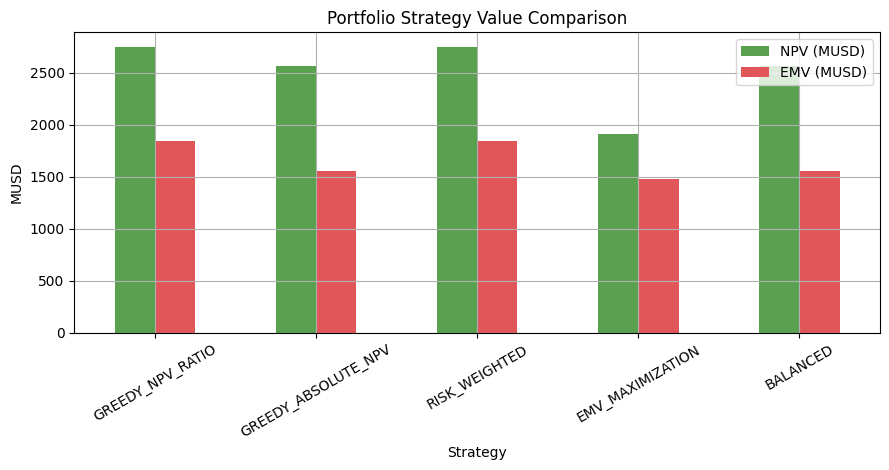

In [9]:
fig, ax = plt.subplots()
portfolio_plot = portfolio_df.set_index("Strategy")[["NPV (MUSD)", "EMV (MUSD)"]]
portfolio_plot.plot(kind="bar", ax=ax, color=["#59A14F", "#E15759"])
ax.set_ylabel("MUSD")
ax.set_title("Portfolio Strategy Value Comparison")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "field_development_portfolio_strategies.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure discussion.** The portfolio view separates project value from expected value. Absolute NPV strategies can favor large developments, while risk-weighted and EMV strategies make probability of success visible. This is the bridge from single-concept economics to capital allocation across fields.

## 4. Export Book-Ready Tables

The report exporter keeps book and notebook tables tied to the same objects used by the calculations.

In [10]:
exporter = FieldDevelopmentReportExporter()
print(exporter.exportTemplateComparisonMarkdown(java_templates))

npv_rows = []
for row in exporter.exportTemplateNpvFigureData(java_templates):
    npv_rows.append({"Case": str(row[0]), "NPV (MUSD)": float(row[1])})
display(pd.DataFrame(npv_rows).round(2))

| Case | Type | CAPEX MUSD | NPV MUSD | Power MW | Lifecycle CO2 kt | P50 resource |
|------|------|------------|----------|----------|------------------|--------------|
| Satellite tieback | Subsea tieback | 830 | -74 | 3.0 | 158.3 | 12.00 GSm3 |
| Standalone FPSO | Standalone FPSO | 1815 | -107 | 2.0 | 22.9 | 120.00 MMbbl |
| Fixed platform | Fixed platform | 1085 | 540 | 2.0 | 31.3 | 150.00 MMbbl |
| Subsea to shore | Subsea-to-shore | 780 | 459 | 3.0 | 126.9 | 35.00 GSm3 |
| Phased brownfield | Phased brownfield expansion | 840 | -151 | 3.0 | 289.3 | 18.00 GSm3 |



,Case,NPV (MUSD)
0,Satellite tieback,-73.73
1,Standalone FPSO,-106.51
2,Fixed platform,540.07
3,Subsea to shore,458.60
4,Phased brownfield,-151.15


## Takeaways

The decision engine provides repeatable teaching cases, transparent MCDA ranking, and project-portfolio optimization without leaving the NeqSim workspace. The same template objects can feed reports, figures, economics, and later process or reservoir-coupling workflows.